In [283]:
from  mobilenetv2.models.imagenet.mbnetv2 import mbnetv2
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math, os
import numpy as np
import cv2

In [284]:
cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]
cfgs = [cfg[2] for cfg in cfgs]

In [285]:
def convert_state_dict(pretrained_sd,cfgs):
    new_sd = {}
    for k, v in pretrained_sd.items():
        # print(f"Converting {k} to ")
        # print(v)
        # First layer mapping
        if k.startswith('features.0'):
            new_key = k.replace('features.0', 'first_conv')
            new_sd[new_key] = v
        # Bottleneck blocks mapping (may need to adjust for all indices)
        elif k.startswith('features'):
            parts = k.split('.')
            block_idx = int(parts[1]) - 1      # because features.0 is first_conv
            # Find the corresponding config
            idx_1 = 0
            idx_2 = 0
            for i, cfg in enumerate(cfgs):
                if sum(cfgs[:i+1]) > block_idx:
                    idx_1 = i
                    idx_2 = block_idx - sum(cfgs[:i])
                    break

            rest = '.'.join(parts[2:])
            new_key = f'bottleneck_sequential_blocks.{idx_1}.{idx_2}.{rest}'
            new_sd[new_key] = v
        # Last layers mapping (if present)
        elif k.startswith('conv'):
            new_sd[k] = v
        elif k.startswith('classifier'):
            new_sd[k] = v
        else:
            # Handle or ignore unexpected keys
            pass
    return new_sd

In [286]:
pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
data_dir = 'datasets/cityscapes_data/data/'


/tmp/ipykernel_5819/3743439510.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')


cuda


## Prepare CityScapes Data
Before proceeding we need to prepare the depth dataset from the depth disparity data provided. I have taken snippets from the following repository to do this. 
- CityScapes Preprocessing - [link](https://github.com/itberrios/CV_projects/blob/main/multitask_depth_seg/data_exploration/cityscapes_dataset_depth_intuition.ipynb)
- Crop noisy parts and resize (seems to be better than relecting on the borders)
- Inpaint and Blur disparity to reduce noise
- Scale to get True disparity values
- Compute depth = b.f/disparity
    - d: depth (meters), b: baseline (meters), f: focal length (pixels), disparity (pixels)
    clip to (0, 500)


In [287]:
class CScapesGTDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, target_transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform
        
        # Build paths for image, depth, and label folders
        self.image_dir = os.path.join(root_dir, split, 'image')
        self.depth_dir = os.path.join(root_dir, split, 'depth') 
        self.label_dir = os.path.join(root_dir, split, 'label')
        
        # Count how many files exist (assuming all folders have same count)
        self.num_samples = 0
        while os.path.exists(os.path.join(self.image_dir, f"{self.num_samples}.npy")):
            self.num_samples += 1
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Build file paths using index
        image_path = os.path.join(self.image_dir, f"{idx}.npy")
        depth_path = os.path.join(self.depth_dir, f"{idx}.npy")
        label_path = os.path.join(self.label_dir, f"{idx}.npy")
        
        # Lazy load: only load when requested
        image = np.load(image_path)
        depth = np.load(depth_path)
        label = np.load(label_path)
        
        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
            
        # Convert to tensors
        image = torch.from_numpy(image).float().permute(2, 0, 1)  # Convert HWC to CHW
        depth = torch.from_numpy(depth).float().permute(2, 0, 1)  # Convert HWC to CHW
        label = torch.from_numpy(label).long().unsqueeze(0)  # Usually labels are long for classification

        return image, depth, label

In [288]:
class CityscapesDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, target_transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform
        
        # Build paths for image, depth, and label folders
        self.image_dir = os.path.join(root_dir, split, 'image')
        self.depth_dir = os.path.join(root_dir, split, 'depth') 
        self.label_dir = os.path.join(root_dir, split, 'label')
        
        # Count how many files exist (assuming all folders have same count)
        self.num_samples = 0
        while os.path.exists(os.path.join(self.image_dir, f"{self.num_samples}.npy")):
            self.num_samples += 1
    
    def __len__(self): 
        return self.num_samples
    
    def __getitem__(self, idx):
        # Build file paths using index
        image_path = os.path.join(self.image_dir, f"{idx}.npy")
        disp_path = os.path.join(self.depth_dir, f"{idx}.npy")
        label_path = os.path.join(self.label_dir, f"{idx}.npy")
        
        # Lazy load: only load when requested
        image = self.rescale_image(np.load(image_path))
        disparity = np.load(disp_path)
        label = self.rescale_image(np.load(label_path),interp_type = cv2.INTER_NEAREST_EXACT)
        
        depth = self.get_depth(disparity)
        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
            
        # Convert to tensors
        image = torch.from_numpy(image).float().permute(2, 0, 1)  # Convert HWC to CHW
        depth = torch.from_numpy(depth).unsqueeze(-1).permute(2, 0, 1).mul(0.2)  # Convert HWC to CHW
        label = torch.from_numpy(label).long().unsqueeze(0)  # Usually labels are long for classification


        return image, depth, label

    def rescale_image(self,image,interp_type = cv2.INTER_LINEAR):
        if len(image.shape) == 3:
            h, w,_ = image.shape
        else:
            # print(image.shape)
            h,w = image.shape
        h2, w2 = int(h*0.9), int(w*0.95)

        image = cv2.resize(image[10:h2,25:w2],(w,h),interpolation=interp_type)

        return image

    def fill_disparity_holes_median(self,disparity_map, kernel_size=5):
        """
        Fill holes using median filtering with valid pixels only
        """
        filled = disparity_map.copy()
        
        # Create mask for holes
        mask = (disparity_map == 0.0)
        hole_coords = np.where(mask)
        
        half_kernel = kernel_size // 2
        
        for y, x in zip(hole_coords[0], hole_coords[1]):
            # Extract neighborhood
            y_min = max(0, y - half_kernel)
            y_max = min(disparity_map.shape[0], y + half_kernel + 1)
            x_min = max(0, x - half_kernel)
            x_max = min(disparity_map.shape[1], x + half_kernel + 1)
            
            neighborhood = disparity_map[y_min:y_max, x_min:x_max]
            valid_values = neighborhood[neighborhood > 0.0]
            
            if len(valid_values) > 0:
                # Use median of valid neighbors
                filled[y, x] = np.median(valid_values)
        
        return filled
    def get_depth(self, disparity):
        # get sizes
        # print(disparity.shape)
        h, w,_ = disparity.shape
        h2, w2 = int(h*0.9), int(w*0.95)


        # remove most noisy bottom area
        # crop bottom noise and resize
        disparity = cv2.resize(disparity[10:h2, 25:w2], (w,h))
        inpaint_radius = 20
        disparity = disparity.astype(np.float32)
        # print(disparity.min(), disparity.max())
        # print(disparity.dtype)
        # disparity = cv2.inpaint(disparity, np.uint8(255*(disparity <= 1)), inpaintRadius=inpaint_radius, flags=cv2.INPAINT_TELEA)

        disparity = self.fill_disparity_holes_median(disparity, kernel_size=5)

        # # blur to reduce noise
        # disparity = cv2.bilateralFilter(disparity, d=2, sigmaColor=15, sigmaSpace=25)

        disparity = cv2.medianBlur(disparity, 5)
        # disparity = cv2.GaussianBlur(disparity, (7, 7), 1.5)

        # disparity[disparity > 0] = (disparity[disparity > 0] - 1) / 256
        baseline = 0.209313 # meters


        # focal lengths (pixels)
        fx = 2262.52 
        fy = 2265.3017905988554 


        depth = baseline * fx / (disparity + 0.1)

        depth = np.clip(depth, 0, 5000)/10
        # print(depth)
        return depth

In [289]:
def depth_to_display(depth_1x1HW: torch.Tensor, cmap='magma'):
    # depth_1x1HW: (1,1,H,W)
    d = depth_1x1HW.detach().cpu().float().squeeze(0).squeeze(0)   # (H,W)
    # remove NaN/Inf and clip robustly using percentiles
    a = d.numpy()
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    # robust range (ignore outliers)
    # vmin, vmax = np.percentile(a, 2), np.percentile(a, 98)
    vmin = np.min(a)
    vmax = np.max(a)
    if vmax <= vmin:
        vmin, vmax = float(a.min()), float(a.max())
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-12)

    # grayscale uint8 for saving
    gray_u8 = (norm * 255).astype(np.uint8)

    # optional colored visualization
    plt.figure(figsize=(4,4))
    plt.imshow(norm, cmap=cmap)  # e.g., 'inferno', 'magma', 'turbo', 'viridis'
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # return a  # HxW uint8


In [290]:
def display_three_tensors(image_tensor, seg_tensor, depth_tensor, titles=None):

    if titles is None:
        titles = ['Image', 'Segmentation', 'Depth']
    
    # Process image tensor
    image_np = image_tensor.permute(1,2,0).detach().cpu().numpy() #CHW with C=3
    seg_np = seg_tensor.detach().cpu().squeeze(0).numpy()  # CHW with C =1
    disparity_np = depth_tensor.detach().cpu().squeeze(0).numpy()  # CHW with C=1


    # Display image
    _, ax = plt.subplots(1, 3, figsize=(20, 8))
    ax[0].imshow(image_np)
    # ax[1].imshow(seg_np, cmap='tab20')
    ax[1].imshow(seg_np, cmap='tab20', vmin=-1, vmax=18)

    ax[2].imshow(disparity_np, cmap='hot')
    
    plt.tight_layout()
    plt.show()

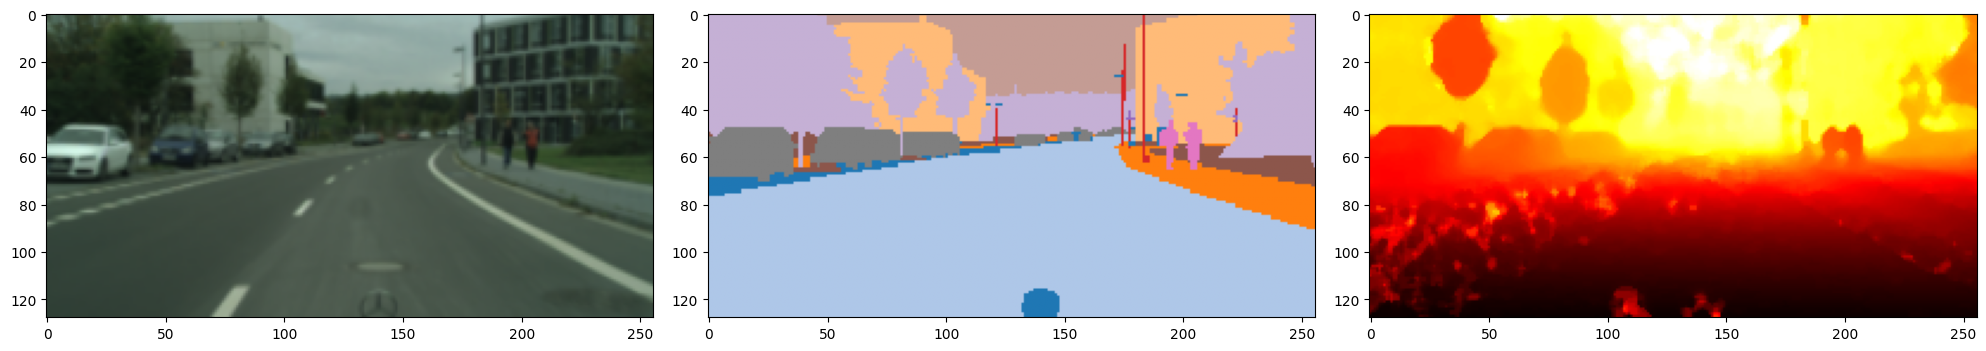

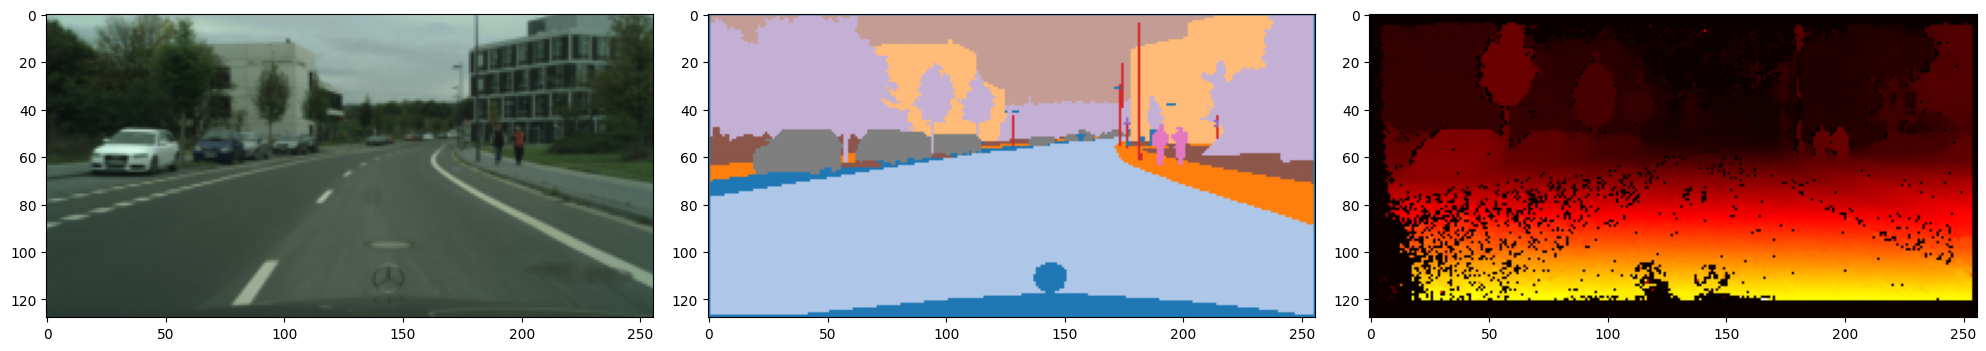

In [291]:
import random
test_idx = random.randint(1, 200)
# test_idx=20
dataset = CityscapesDataset(data_dir)
val_dataset = CityscapesDataset(data_dir, split='val')

test_image, test_depth, test_labels = dataset[test_idx]
display_three_tensors(test_image, test_labels, test_depth)


gt_dataset = CScapesGTDataset(data_dir)
gt_image, gt_disp, gt_seg = gt_dataset[test_idx]
display_three_tensors(gt_image, gt_seg, gt_disp)

In [292]:
print(torch.max(test_depth),torch.min(test_depth))

tensor(94.7053) tensor(21.4031)


In [293]:
test_image.shape, test_depth.shape, test_labels.shape

(torch.Size([3, 128, 256]),
 torch.Size([1, 128, 256]),
 torch.Size([1, 128, 256]))

In [294]:
train_dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers = True
)

test_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [295]:
for batch in train_dataloader:
    images, depths, labels = batch
    # print(images.shape, depths.shape, labels.shape)
    break

### Model Classes


In [296]:
def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )

class PixelShuffleX2(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        self.ps = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = self.ps(x)
        return x

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup

        if expand_ratio == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
    
    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [297]:
class UpsampleConv(nn.Module):
    """Bilinear upsample + conv. Zero checkerboard artifacts."""
    def __init__(self, in_channels, out_channels, scale_factor=2):
        super().__init__()
        self.up = nn.Upsample(scale_factor=scale_factor, mode='bilinear', align_corners=False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(self.up(x))))


In [298]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        pixel = PixelShuffleX2

        up1 = UpsampleConv(320, 80)
        up2 = UpsampleConv(120, 30)
        up3 = UpsampleConv(48, 12)
        up4 = UpsampleConv(32, 2,scale_factor=4)


        bottleneck = InvertedResidual
        self.classes = 20
        self.layer1 = nn.Sequential(
            pixel(2),
            # up1,
            # nn.GroupNorm(8,80),
            bottleneck(80, 24, stride=1, expand_ratio=1),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6)
        )
        self.depth_conv_1 = nn.Conv2d(24, 1,kernel_size=1,bias=False)
        self.segm_conv_1 = nn.Conv2d(24, self.classes, kernel_size=1,bias=False)

        self.layer2 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(6,30),
            # up2,
            bottleneck(30, 16, stride=1, expand_ratio=3),
            bottleneck(16, 16, stride=1, expand_ratio=6),
            bottleneck(16, 16, stride=1, expand_ratio=6)
        )
        self.depth_conv_2 = nn.Conv2d(16, 1,kernel_size=1,bias=False)
        self.segm_conv_2 = nn.Conv2d(16, self.classes, kernel_size=1,bias=False)


        self.layer3 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(4,12),
            # up3,
            bottleneck(12, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_3 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_3 = nn.Conv2d(8, self.classes, kernel_size=1,bias=False)

        self.layer4 = nn.Sequential(
            pixel(4),
            # nn.GroupNorm(1,2),
            # up4,
            bottleneck(2, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_4 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_4 = nn.Conv2d(8, self.classes, kernel_size=1,bias=False)

    def forward(self, x, skips):
        depth_imgs=[]
        segm_imgs=[]
        # segm_values = torch.arange(-1, 19, dtype=torch.float32)  # Shape: (20,)
        # segm_values = segm_values.view(1, 20, 1, 1)  # Shape: (1, 20, 1, 1)   
        # max_indices = torch.argmax(probs, dim=1, keepdim=True)  # Shape: (B, 1, H, W)
        out1 = self.layer1(x)
        # print(x.shape)
        depth_imgs.append(self.depth_conv_1(out1))
        segm_imgs.append(self.segm_conv_1(out1))

        out1 = torch.cat((out1, skips[4]), dim=1)  # Skip connection
        out2 = self.layer2(out1)
        depth_imgs.append(self.depth_conv_2(out2))
        segm_imgs.append(self.segm_conv_2(out2))

        out2 = torch.cat((out2, skips[2]), dim=1)  # Skip connection
        out3 = self.layer3(out2)
        depth_imgs.append(self.depth_conv_3(out3))
        segm_imgs.append(self.segm_conv_3(out3))

        out3 = torch.cat((out3, skips[1]), dim=1)  # Skip connection
        out4 = self.layer4(out3)
        depth_imgs.append(self.depth_conv_4(out4))
        segm_imgs.append(self.segm_conv_4(out4))

        depth_imgs = [img.squeeze(dim=1).to(torch.float32) for img in depth_imgs] # (B, H, W)
        segm_imgs = [img.to(torch.float32) for img in segm_imgs] # (B, C, H, W)
        return depth_imgs, segm_imgs

In [299]:
class MainModel(nn.Module):
    def __init__(self,pretrained_sd,tag = "train"):
        super().__init__()
        self.encoder = mbnetv2() 
        if tag == "train":
            converted_sd = convert_state_dict(pretrained_sd, cfgs)
            self.encoder.load_state_dict(converted_sd)

            for i in self.encoder.parameters():
                i.requires_grad = False

        self.decoder = Decoder()

    def forward(self, x):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out[0], enc_out[1])
        return dec_out

In [300]:
model = MainModel(pretrained_sd,"train")
model.to(device)


Initializing weights...


MainModel(
  (encoder): MobileNetV2(
    (first_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (bottleneck_sequential_blocks): ModuleList(
      (0): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
            (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(16, 96, kernel_size=(1, 1), str

In [301]:
# state = torch.load('saves/cityscapes_v2.pth')
# # state_dict = torch.load('model.pth')
# model.load_state_dict(state)
# # model.eval()

Testing the Dataset with model


In [302]:
img_tensor, depth_tensor,seg_tensor = dataset[test_idx]
img_tensor = img_tensor.to(device)
img_tensor = img_tensor.unsqueeze(0)
depth_tensor = depth_tensor.unsqueeze(0)
depth_tensor = depth_tensor.to(device)
seg_tensor = seg_tensor.to(device)

In [303]:
dec_out, seg_out = model(img_tensor)
print("Decoder output shapes:")
for i in dec_out:
    print(i.shape)

Decoder output shapes:
torch.Size([1, 8, 16])
torch.Size([1, 16, 32])
torch.Size([1, 32, 64])
torch.Size([1, 128, 256])


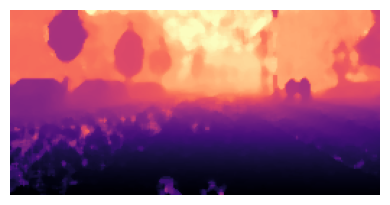

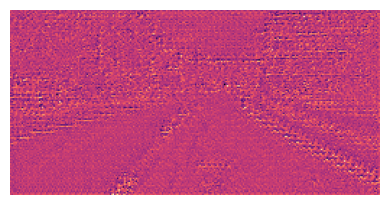

In [304]:
depth_to_display(depth_tensor)  # (1,1,H,W)
depth_to_display(dec_out[-1])  # (1,1,H,W)

In [305]:
torch.max(depth_tensor-dec_out[3])

tensor(96.6230, device='cuda:0', grad_fn=<MaxBackward1>)

In [306]:
torch.min(depth_tensor), torch.max(depth_tensor)

(tensor(21.4031, device='cuda:0'), tensor(94.7053, device='cuda:0'))

### LOSS FUNCTIONS


In [307]:
class MultiScaleDepthLoss(nn.Module):
    def __init__(self, m=10, M=100, depth_scale=[1,1,1,1]): # depth values normalised to 0-100 hence this choice of m and M
        super(MultiScaleDepthLoss, self).__init__()
        self.m = m
        self.M = M
        self.depth_scale = depth_scale

        # Pre-calculate constants for the G(d) transform for efficiency
        self.log_m = math.log(self.m)
        self.log_M = math.log(self.M)
        self.log_M_minus_log_m = self.log_M - self.log_m

    def _g_transform(self, d):
        # Use sigmoid-based soft clamping instead of hard clamp
        # This preserves gradients everywhere
        eps = 1e-6
        d_normalized = torch.sigmoid((d - self.m) / (self.M - self.m + eps))
        d_soft_clamped = d_normalized * (self.M - self.m) + self.m
        
        log_d = torch.log(d_soft_clamped + eps)  # Add small epsilon to avoid log(0)
        
        return (log_d - self.log_m) * self.M / self.log_M_minus_log_m


    def _berhu_loss(self, diff, c):
        # print("c value:",c)
        # L1 loss for small differences
        l1_loss = diff
        
        # L2-like loss for large differences
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        # Combine using a mask
        mask = diff <= c
        return torch.where(mask, l1_loss, l2_loss)

    def forward(self, pred_depths, gt_depth):

        total_loss = 0.0
        scale = [0.3, 0.5, 0.75, 1.0]
        # Iterate through each predicted depth map scale
        for i,pred_d in enumerate(pred_depths):
            # Get the height and width of the current prediction scale
            _, H_i, W_i = pred_d.shape            
            resized_gt_d = F.interpolate(gt_depth, size=(H_i, W_i), mode='bilinear', align_corners=True)
            resized_gt_d = resized_gt_d.squeeze(dim=1).to(torch.float32)
            
            # Apply the G-transform to both prediction and resized ground truth
            pred_g = self._g_transform(pred_d)
            gt_g = self._g_transform(resized_gt_d)

            # Calculate the absolute difference in the transformed space
            diff = torch.abs(pred_g - gt_g)
            
            # Calculate the dynamic threshold 'c' (20% of the max difference in the batch)
            c = 0.2 * torch.max(diff).detach()
            
            # Calculate the BerHu loss for every pixel
            berhu_pixel_losses = self._berhu_loss(diff, c)
            # Calculate the mean loss for the current scale and add it to the total
            scale_loss = torch.sum(berhu_pixel_losses) / ( H_i * W_i)  # Average over batch and spatial dimensions
            total_loss += scale_loss.mul(self.depth_scale[i])
            
        return total_loss

In [308]:
class MultiScaleSegmLoss(nn.Module):
    def __init__(self, segm_scale=[1,1,1,1]):
        super().__init__()
        self.segm_scale = segm_scale
        # Inverse frequency weighting (after +1 shift, class 0=void ignored)
        # Weights for classes 1..19 (mapped from GT 0..18)
        class_weights = torch.tensor([
            0.0,    # void (ignore)
            0.0115, 0.0698, 0.0186, 0.6477, 0.4832,
            0.3437, 2.0468, 0.7717, 0.0267, 0.3665,
            0.1055, 0.3485, 3.1430, 0.0607, 1.5879,
            1.8078, 1.8238, 4.3106, 1.0261
        ])
        # class 0 (void) weight = 0 since ignore_index handles it
        # weights = torch.cat([torch.tensor([0.0]), 1.0 / freqs])
        # weights = weights / weights[1:].mean()  # normalize
        self.register_buffer('class_weights', class_weights)

    def forward(self, segm_preds, segm_gt):
        total_loss = 0.0
        segm_gt = segm_gt + 1  # [-1..18] -> [0..19]
        if len(segm_gt.shape) == 3:
            segm_gt = segm_gt.unsqueeze(0)

        for i, pred in enumerate(segm_preds):
            B, _, H, W = pred.shape
            tgt = F.interpolate(segm_gt.float(), size=(H, W),
                                mode="nearest").squeeze(1).long()
            stage_loss = F.cross_entropy(
                pred, tgt,
                weight=self.class_weights.to(pred.device),
                ignore_index=0
            )
            total_loss += stage_loss.mul(self.segm_scale[i])
        return total_loss


In [309]:
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, data_range=1.0, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.data_range = data_range
        self.size_average = size_average
        
        # Create Gaussian window (1, 1, window_size, window_size)
        self.window = self._create_window(window_size)
        
    def _gaussian(self, window_size, sigma=1.5):
        gauss = torch.Tensor([
            math.exp(-(x - window_size//2)**2 / (2*sigma**2)) 
            for x in range(window_size)
        ])
        return gauss / gauss.sum()
    
    def _create_window(self, window_size):
        _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float()
        window = _2D_window.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 11, 11)
        return window
    
    def forward(self, pred, target):
        pred = pred[-1]
        # Add channel dimension: (B, H, W) -> (B, 1, H, W)
        if pred.dim() == 3:
            pred = pred.unsqueeze(1)
            # target = target.unsqueeze(1)
        
        # batch_size = pred.size(0)
        
        # Ensure window is on same device
        if self.window.device != pred.device:
            self.window = self.window.to(pred.device)
        
        # Use the single-channel window
        window = self.window
        
        # Compute local means
        mu1 = F.conv2d(pred, window, padding=self.window_size//2)
        mu2 = F.conv2d(target, window, padding=self.window_size//2)
        
        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2
        
        # Compute local variances and covariance
        sigma1_sq = F.conv2d(pred * pred, window, padding=self.window_size//2) - mu1_sq
        sigma2_sq = F.conv2d(target * target, window, padding=self.window_size//2) - mu2_sq
        sigma12 = F.conv2d(pred * target, window, padding=self.window_size//2) - mu1_mu2
        
        # SSIM constants
        C1 = (0.01 * self.data_range) ** 2
        C2 = (0.03 * self.data_range) ** 2
        
        # SSIM formula
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Average over spatial dimensions, optionally over batch
        if self.size_average:
            return 1 - ssim_map.mean()  # Convert to loss
        else:
            return 1 - ssim_map.mean(dim=[1, 2, 3])  # Per-batch losses

In [310]:
def edge_aware_smoothness_loss( pred, depth):    
    # Compute gradients
    pred = pred[-1]
    depth = depth.squeeze(dim=1).to(torch.float32)
    depth_grad_x = torch.abs(depth[:, :, :-1] - depth[:, :, 1:])
    depth_grad_y = torch.abs(depth[:, :-1, :] - depth[:, 1:, :])

    image_grad_x = torch.abs(pred[:,  :, :-1] - pred[:,  :, 1:])
    image_grad_y = torch.abs(pred[:,  :-1, :] - pred[:, 1:, :])

    # Edge-aware weighting
    smooth_x = depth_grad_x * torch.exp(-image_grad_x)
    smooth_y = depth_grad_y * torch.exp(-image_grad_y)
    # loss = torch.sum(torch.abs(depth_grad_x - image_grad_x)) + torch.sum(torch.abs(depth_grad_y - image_grad_y))
    # loss /= (pred.size(1) * pred.size(2))

    return torch.mean(smooth_x) + torch.mean(smooth_y)


In [311]:
test_dept_loss = MultiScaleDepthLoss()
test_segm_loss = MultiScaleSegmLoss()
ssim_loss = SSIMLoss()
print("Segm shapes:", seg_out[0].shape, seg_tensor.shape)
print("Depth shapes:", dec_out[0].shape, depth_tensor.shape)
print("Depth Loss:", test_dept_loss(dec_out, depth_tensor).item())
print("Segmentation Loss:", test_segm_loss(seg_out, seg_tensor).item())
print("SSIM Loss:", ssim_loss(dec_out, depth_tensor).item())
# print()
print("Edge-aware smoothness Loss:", edge_aware_smoothness_loss(dec_out, depth_tensor).item())

Segm shapes: torch.Size([1, 20, 8, 16]) torch.Size([1, 128, 256])
Depth shapes: torch.Size([1, 8, 16]) torch.Size([1, 1, 128, 256])
Depth Loss: 75.03096008300781
Segmentation Loss: 13.544754981994629
SSIM Loss: 0.9999929070472717
Edge-aware smoothness Loss: 0.7257000803947449


## Dataset Prep


In [312]:
def train_multi_scale_depth_model(model, dataloader, num_epochs=100, lr=1e-2, depth_scale=[1,1,1,1], segm_scale=[1,1,1,1]):
    # Initialize loss function and optimizer
    depth_loss = MultiScaleDepthLoss(depth_scale=depth_scale)
    segm_loss = MultiScaleSegmLoss(segm_scale=segm_scale)
    ssim_loss = SSIMLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    # Paper uses StepLR with 10% decay per epoch
    scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
    
    model.train()
    Loss_history = []
    
    # Initialize data iterator
    data_iter = iter(dataloader)
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        # Step-based setup: exactly 1000 steps per epoch
        for step in range(500):
            try:
                color_input, depth_gt, labels = next(data_iter)
            except StopIteration:
                data_iter = iter(dataloader)
                color_input, depth_gt, labels = next(data_iter)

            color_input = color_input.to(device, non_blocking=True).float()
            depth_gt = depth_gt.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).int()
            
            optimizer.zero_grad()
            
            # Forward pass through model
            depth_predictions, segprob_predictions = model(color_input)

            # Total loss calculation (including edge-aware smoothness loss)
            total_loss = (
                depth_loss(depth_predictions, depth_gt)
                + segm_loss(segprob_predictions, labels)
                # + 5 * edge_aware_smoothness_loss(depth_predictions, depth_gt)
                # + ssim_loss(depth_predictions, depth_gt)
            )

            # Backward pass and optimize
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress every 100 steps
            if step % 10 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Step {step}/500, '
                      f'Total Loss: {total_loss.item():.4f}',end='\r')
                Loss_history.append(total_loss.item())

        # Step the scheduler once at the end of each epoch
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1} completed. Average Loss: {epoch_loss/500:.4f}, LR: {current_lr:.6f}')
        
    return Loss_history


In [313]:
# depth_scale = [0.5, 0.7, 0.9, 1.0]
# segm_scale  = [2.5, 3.5, 4.5, 5.0] # bump up segm relative to depth
depth_scale =[0.25]*4
segm_scale = [0.75]*4

In [314]:
Loss_history = train_multi_scale_depth_model(model, train_dataloader, num_epochs=40, lr=2e-2, depth_scale=depth_scale, segm_scale=segm_scale)

Epoch 1 completed. Average Loss: 32.9642, LR: 0.018000
Epoch 2 completed. Average Loss: 18.2156, LR: 0.016200
Epoch 3 completed. Average Loss: 17.4443, LR: 0.014580
Epoch 4 completed. Average Loss: 16.9547, LR: 0.013122
Epoch 5 completed. Average Loss: 16.4973, LR: 0.011810
Epoch 6 completed. Average Loss: 16.1479, LR: 0.010629
Epoch 7 completed. Average Loss: 15.8845, LR: 0.009566
Epoch 8 completed. Average Loss: 15.5848, LR: 0.008609
Epoch 9 completed. Average Loss: 15.3972, LR: 0.007748
Epoch 10 completed. Average Loss: 15.1687, LR: 0.006974
Epoch 11 completed. Average Loss: 14.9966, LR: 0.006276
Epoch 12 completed. Average Loss: 14.8188, LR: 0.005649
Epoch 13 completed. Average Loss: 14.7186, LR: 0.005084
Epoch 14 completed. Average Loss: 14.5838, LR: 0.004575
Epoch 15 completed. Average Loss: 14.4528, LR: 0.004118
Epoch 16 completed. Average Loss: 14.3080, LR: 0.003706
Epoch 17 completed. Average Loss: 14.2586, LR: 0.003335
Epoch 18 completed. Average Loss: 14.1685, LR: 0.003002
E

# Results and Analysis

**TO-DO's**
- Make the code modular so that it fits with any dataset.
- Check with higher res images
- Organise and mention tensor shapes at each point to prevent confusion later on. Try to keep same shapes at same levels.

In [315]:
img_tensor, depth_tensor,seg_tensor = val_dataset[46]
img_tensor = img_tensor.to(device)
img_tensor = img_tensor.unsqueeze(0)
depth_tensor = depth_tensor.unsqueeze(0)
depth_tensor = depth_tensor.to(device)
seg_tensor = seg_tensor.unsqueeze(0)
seg_tensor = seg_tensor.to(device)


tensor(8.0958, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0, device='cuda:0') tensor(18, device='cuda:0')
tensor(-1, device='cuda:0') tensor(18, device='cuda:0')


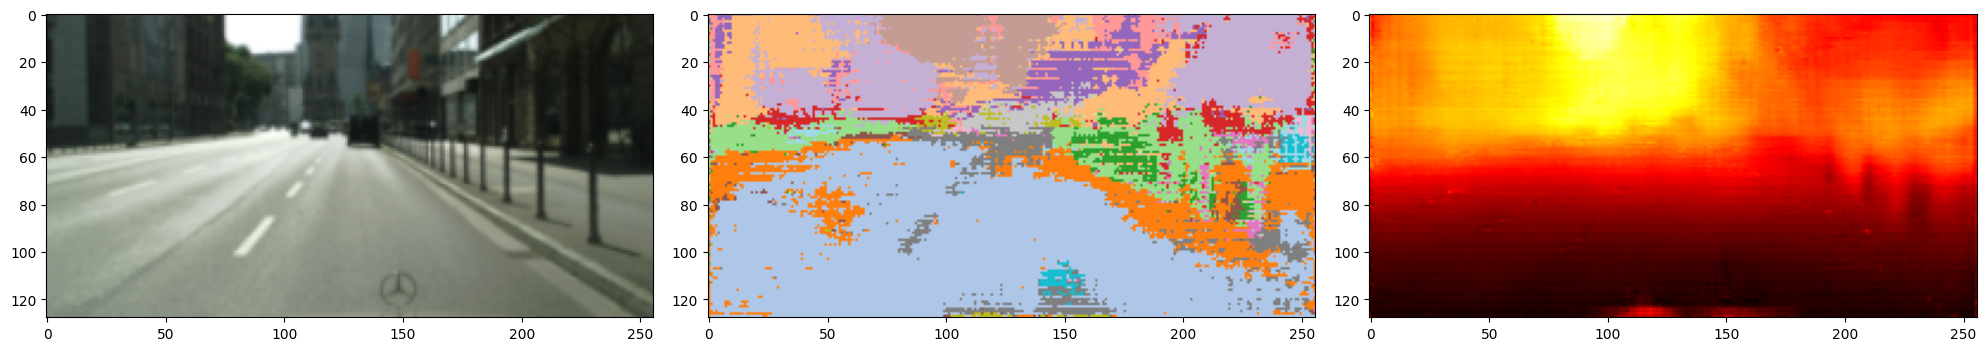

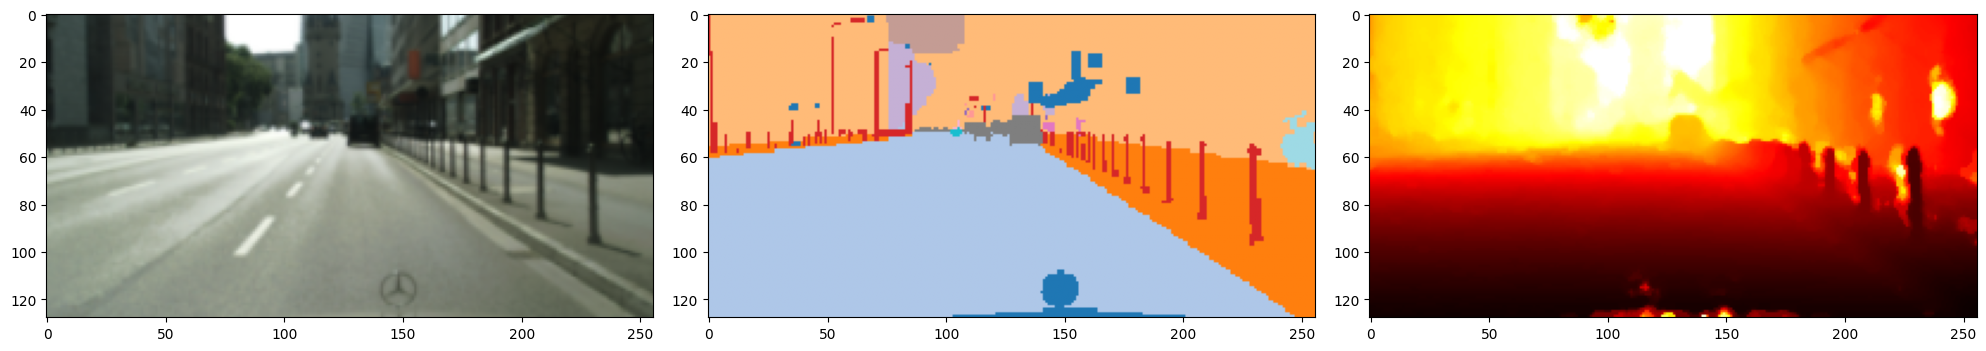

In [316]:
segmented_image = torch.argmax(segm[3], dim=1, keepdim=True) -1 # convert back to -1 - 18
# print()
print(torch.max(segm[3][0][19][:][:]))
print(torch.min(segmented_image), torch.max(segmented_image))
print(torch.min(seg_tensor),torch.max(seg_tensor))
# print(segmented_image[-1]-seg_tensor)
# print()
display_three_tensors(img_tensor.squeeze(0), segmented_image.squeeze(0), output[3])
display_three_tensors(img_tensor.squeeze(0), seg_tensor.squeeze(0), depth_tensor.squeeze(0))


In [317]:
torch.save(model.state_dict(), 'saved_models/cityscapes_v5.pth')

Text(0.5, 1.0, 'Training Loss Curve')

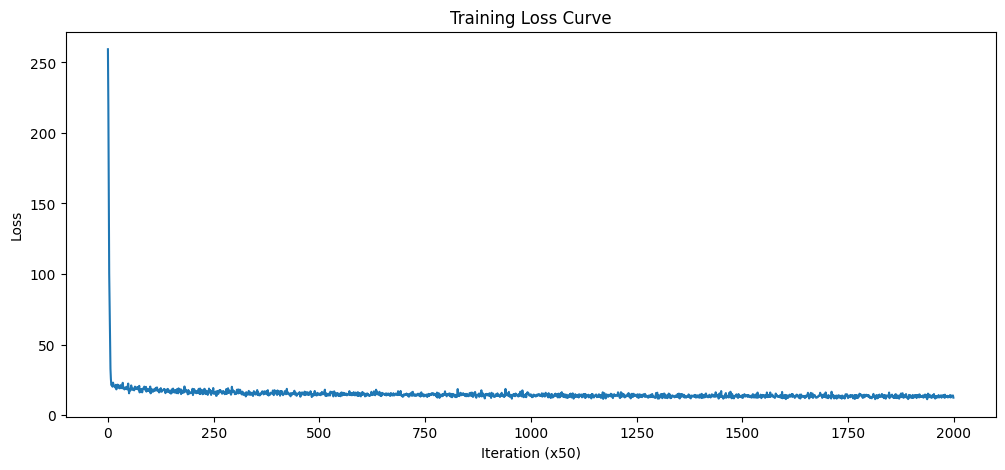

In [318]:
#LOSS Curve
plt.figure(figsize=(12,5))
plt.plot(Loss_history)
plt.xlabel('Iteration (x50)')
plt.ylabel('Loss')  
plt.title('Training Loss Curve')

#### Model Size

In [319]:
mbnetv2 = mbnetv2()
encoder_params = sum(p.numel() for p in mbnetv2.parameters())
print(f'Encoder parameters: {encoder_params}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params}')
print(f'Total decoder parameters: {total_params - encoder_params}')


Initializing weights...
Encoder parameters: 3504872
Total number of parameters: 3556346
Total decoder parameters: 51474


In [320]:
def rmse(pred, target):
    pred = pred[-1]
    return torch.sqrt(torch.mean((pred - target) ** 2))

In [321]:
rmse(output, depth_tensor)

tensor(6.7119, device='cuda:0', grad_fn=<SqrtBackward0>)

In [322]:
print(torch.max(output[3]).item(),
torch.max(depth_tensor).item(),
torch.min(torch.abs(output[3]-depth_tensor)).item())

98.82691192626953 94.70280456542969 3.4332275390625e-05


In [323]:
def smooth_depth_prediction(depth_tensor, kernel_size=2):
    """Apply Gaussian smoothing to reduce noise"""
    import torch.nn.functional as F
    
    # Create Gaussian kernel
    sigma = kernel_size / 3.0
    kernel_1d = torch.exp(-0.5 * (torch.arange(kernel_size) - kernel_size//2)**2 / sigma**2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    
    # 2D separable Gaussian
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.unsqueeze(0).unsqueeze(0).to(depth_tensor.device)
    
    # Apply smoothing
    smooth_depth = F.conv2d(depth_tensor, kernel_2d, padding=kernel_size//2)
    return smooth_depth

# Use during inference
with torch.no_grad():
    raw_pred = model(img_tensor)
    smooth_pred = smooth_depth_prediction(raw_pred[0][-1])


In [324]:
def refine_segmentation_guided_filter(image_np, probs_np, r=5, eps=1e-4):
    """Refines segmentation maps using the input RGB image as a guide."""
    if image_np.shape[0] == 3:
        image_np = np.transpose(image_np, (1, 2, 0))
    if image_np.dtype != np.uint8:
        image_np = (image_np * 255.0).clip(0, 255).astype(np.uint8)
            
    if probs_np.shape[0] < probs_np.shape[2]:  # (C, H, W) -> (H, W, C)
        probs_np = np.transpose(probs_np, (1, 2, 0))
        
    H, W, C = probs_np.shape
    refined_probs = np.zeros_like(probs_np)
    
    for c in range(C):
        prob_slice = probs_np[:, :, c].astype(np.float32)
        try:
            refined_probs[:, :, c] = cv2.ximgproc.guidedFilter(
                guide=image_np, src=prob_slice, radius=r, eps=eps
            )
        except AttributeError:
            # Fallback to bilateral filtering if opencv-contrib is not installed
            prob_uint8 = (prob_slice * 255).astype(np.uint8)
            refined_uint8 = cv2.bilateralFilter(prob_uint8, d=2*r+1, sigmaColor=75, sigmaSpace=75)
            refined_probs[:, :, c] = refined_uint8.astype(np.float32) / 255.0
            
    return np.argmax(refined_probs, axis=2)

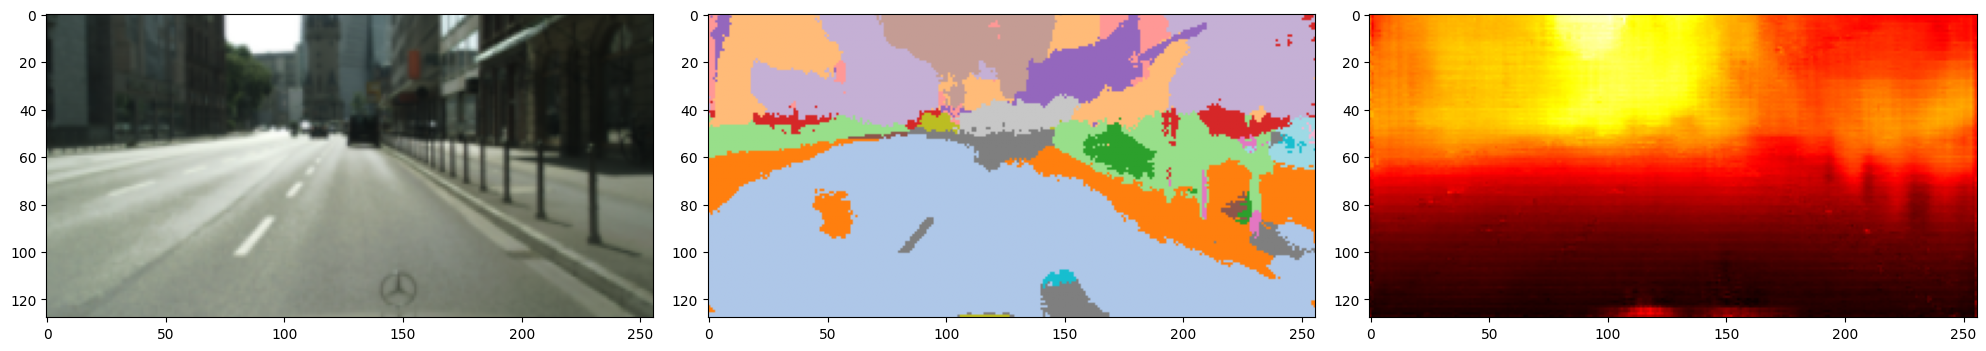

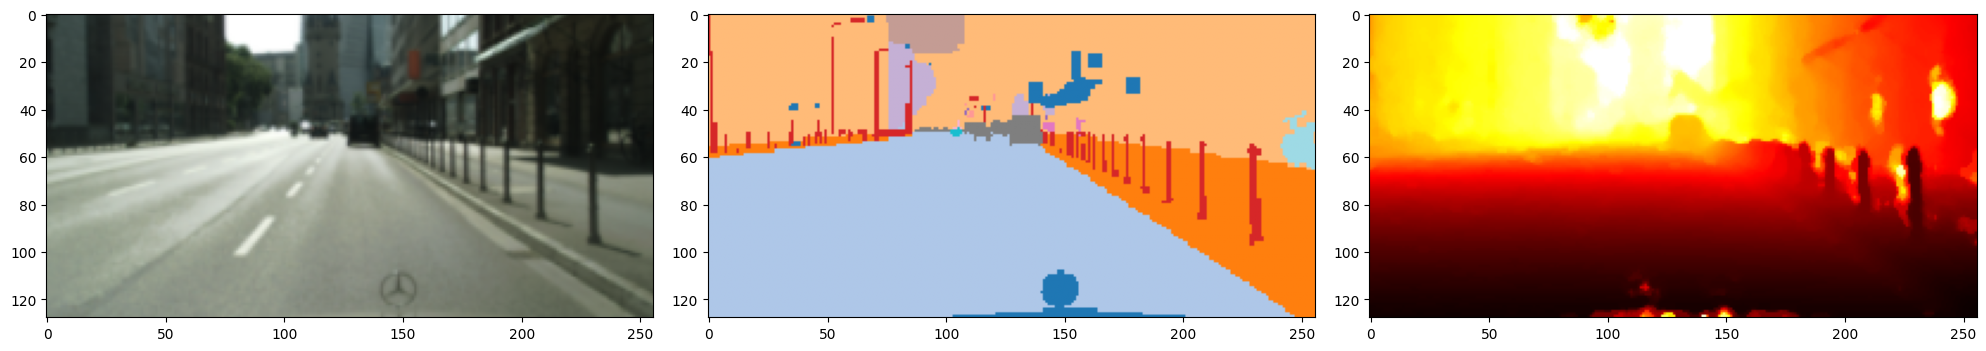

In [325]:
# 1. Convert segmentation logits to probabilities via softmax
probs = torch.softmax(segm[3], dim=1).squeeze(0).detach().cpu().numpy()  # (20, H, W)

# 2. Extract and unnormalize the input image (using ImageNet mean and std)
img_np = img_tensor.squeeze(0).detach().cpu().numpy()
mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
unnorm_img = img_np * std + mean  # Float [0, 1]

# 3. Apply the guided filter refinement
refined_argmax = refine_segmentation_guided_filter(unnorm_img, probs, r=5, eps=1e-4)

# 4. Map the class index back to the target label range [-1, 18]
refined_seg = torch.tensor(refined_argmax - 1, device=device).unsqueeze(0)

# 5. Display the results
display_three_tensors(img_tensor.squeeze(0), refined_seg.squeeze(0), output[3])
display_three_tensors(img_tensor.squeeze(0), seg_tensor.squeeze(0), depth_tensor.squeeze(0))


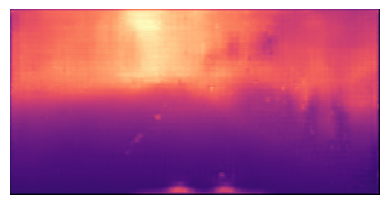

In [326]:
depth_to_display(smooth_pred)

## Depth Benchmark

In [327]:
from scripts.depth_benchmark import DepthBenchmark

In [328]:
# Single image benchmark  (align='lsq' normalises both to [0,1] via least-squares fit)
bench = DepthBenchmark(min_depth=15, max_depth=100.0, align='lsq')

model.eval()
with torch.no_grad():
    depth_preds, _ = model(img_tensor)

single_result = bench.evaluate(depth_preds[-1], depth_tensor)
bench.print_results(single_result)

═════════════════════════════════════════════
  Relative Depth Benchmark Results
═════════════════════════════════════════════
  Valid pixels : 32768
─────────────────────────────────────────────
  AbsRel       : 0.1415
  SqRel        : 0.0122
  RMSE         : 0.0623
  RMSE (log)   : 0.2227
  SILog        : 22.1422
─────────────────────────────────────────────
  δ < 1.25     : 0.8142
  δ < 1.25²    : 0.9567
  δ < 1.25³    : 0.9847
─────────────────────────────────────────────
  Spearman ρ   : 0.9793
  Ordinal Acc  : 0.9534
═════════════════════════════════════════════


In [329]:
# Full dataset benchmark
dataset_result = bench.evaluate_dataset(model, test_dataloader, device)
bench.print_results(dataset_result)

═════════════════════════════════════════════
  Relative Depth Benchmark Results
═════════════════════════════════════════════
  Valid pixels : 16383999
─────────────────────────────────────────────
  AbsRel       : 3.2081
  SqRel        : 0.4384
  RMSE         : 0.0785
  RMSE (log)   : 0.3088
  SILog        : 30.3103
─────────────────────────────────────────────
  δ < 1.25     : 0.7703
  δ < 1.25²    : 0.9131
  δ < 1.25³    : 0.9565
─────────────────────────────────────────────
  Spearman ρ   : 0.9481
  Ordinal Acc  : 0.9171
═════════════════════════════════════════════
